<a href="https://colab.research.google.com/github/sarmuh/Bank-Customer-Churn-ML/blob/main/CUSTOMER_CHURN_P3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [74]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.linear_model import LogisticRegression,RidgeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.dummy import DummyClassifier

#SMOTE
from sklearn.cluster import MiniBatchKMeans
from imblearn.over_sampling import KMeansSMOTE

from sklearn.metrics import classification_report,f1_score,confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("/content/BANK_CUSTOMER_CHURN.csv")
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,0,1


In [7]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


In [13]:
df_0 = df[df['Exited'] == 0].sample(5000)
df_1 = df[df['Exited'] == 1]

In [15]:
df_v = pd.concat([df_0,df_1])
df_v['Exited'].value_counts()

,count
Exited,
0,5000
1,2037


In [16]:
X = df_v.drop('Exited',axis=1)
y = df_v['Exited']
X.shape,y.shape

((7037, 12), (7037,))

In [33]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=12)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((5629, 12), (1408, 12), (5629,), (1408,))

In [50]:
#SMOTining
esti = MiniBatchKMeans(n_clusters=50,random_state=11)
sm = KMeansSMOTE(kmeans_estimator=esti,random_state=14)

X_train_sm,y_train_sm = sm.fit_resample(X_train,y_train)

In [80]:
y_train_sm.value_counts()

,count
Exited,
1,4010
0,4010


In [68]:
models_tree = {
  'DecisionTreeClassifier' : DecisionTreeClassifier(),
  'RandomForestClassifier' : RandomForestClassifier(n_estimators=250),
  'XGBClassifier' : XGBClassifier(verbosity=0),
  'LGBMClassifier' : LGBMClassifier(verbose=-1),
  'CatBoostClassifier': CatBoostClassifier(verbose=False)
  }

--------- DecisionTreeClassifier model --------------------


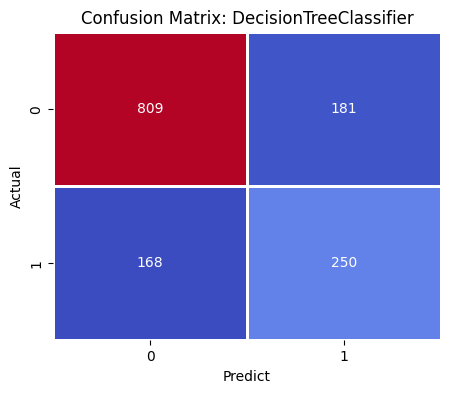

              precision    recall  f1-score   support

           0       0.83      0.82      0.82       990
           1       0.58      0.60      0.59       418

    accuracy                           0.75      1408
   macro avg       0.70      0.71      0.71      1408
weighted avg       0.75      0.75      0.75      1408

----------------------------------------------------------------------------------------------------
--------- RandomForestClassifier model --------------------


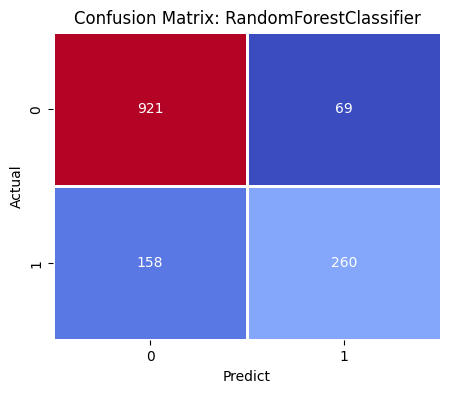

              precision    recall  f1-score   support

           0       0.85      0.93      0.89       990
           1       0.79      0.62      0.70       418

    accuracy                           0.84      1408
   macro avg       0.82      0.78      0.79      1408
weighted avg       0.83      0.84      0.83      1408

----------------------------------------------------------------------------------------------------
--------- XGBClassifier model --------------------


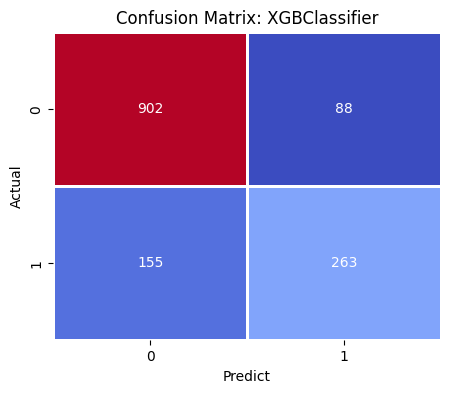

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       990
           1       0.75      0.63      0.68       418

    accuracy                           0.83      1408
   macro avg       0.80      0.77      0.78      1408
weighted avg       0.82      0.83      0.82      1408

----------------------------------------------------------------------------------------------------
--------- LGBMClassifier model --------------------


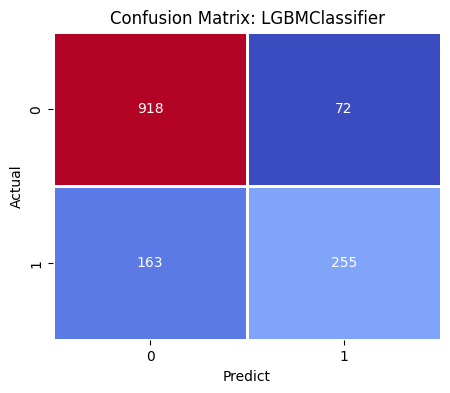

              precision    recall  f1-score   support

           0       0.85      0.93      0.89       990
           1       0.78      0.61      0.68       418

    accuracy                           0.83      1408
   macro avg       0.81      0.77      0.79      1408
weighted avg       0.83      0.83      0.83      1408

----------------------------------------------------------------------------------------------------
--------- CatBoostClassifier model --------------------


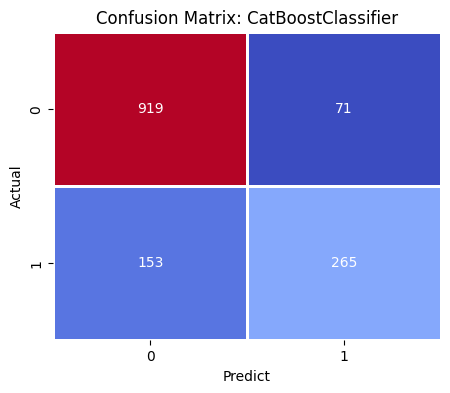

              precision    recall  f1-score   support

           0       0.86      0.93      0.89       990
           1       0.79      0.63      0.70       418

    accuracy                           0.84      1408
   macro avg       0.82      0.78      0.80      1408
weighted avg       0.84      0.84      0.84      1408

----------------------------------------------------------------------------------------------------


In [60]:
for name,model in models_tree.items():
  print(f'--------- {name} model --------------------')
  model.fit(X_train_sm,y_train_sm)
  y_pred = model.predict(X_test)

  plt.figure(figsize=(5, 4))
  plt.title(f"Confusion Matrix: {name}")
  sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,linewidths=1,cbar=False,cmap='coolwarm',fmt='d')
  plt.ylabel('Actual')
  plt.xlabel('Predict')
  plt.show()

  print(classification_report(y_test,y_pred))
  print('-----'*20)


In [76]:
#Standardization

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_sm)
X_test_s = scaler.transform(X_test)

In [77]:
models = {
'LogisticRegression' : LogisticRegression(max_iter=250,verbose=0),
'RidgeClassifier' : RidgeClassifier(max_iter=300),
'SVC' : SVC(verbose=0),
'KNeighborsClassifier' : KNeighborsClassifier(n_neighbors=7),
'BernoulliNB' : BernoulliNB(),
'DummyClassifier' : DummyClassifier()
}


--------- LogisticRegression model --------------------


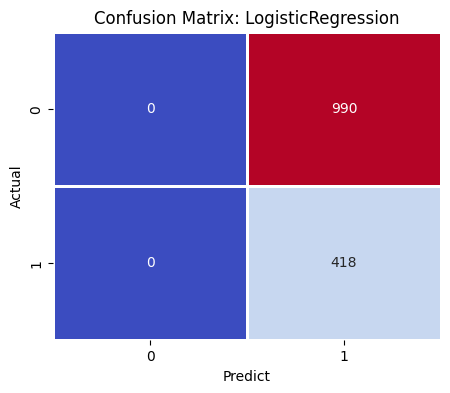

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       990
           1       0.30      1.00      0.46       418

    accuracy                           0.30      1408
   macro avg       0.15      0.50      0.23      1408
weighted avg       0.09      0.30      0.14      1408

----------------------------------------------------------------------------------------------------
--------- RidgeClassifier model --------------------


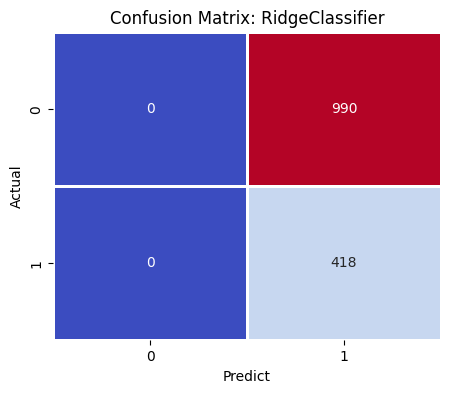

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       990
           1       0.30      1.00      0.46       418

    accuracy                           0.30      1408
   macro avg       0.15      0.50      0.23      1408
weighted avg       0.09      0.30      0.14      1408

----------------------------------------------------------------------------------------------------
--------- SVC model --------------------


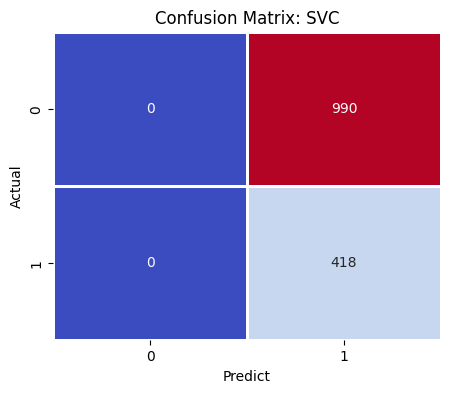

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       990
           1       0.30      1.00      0.46       418

    accuracy                           0.30      1408
   macro avg       0.15      0.50      0.23      1408
weighted avg       0.09      0.30      0.14      1408

----------------------------------------------------------------------------------------------------
--------- KNeighborsClassifier model --------------------


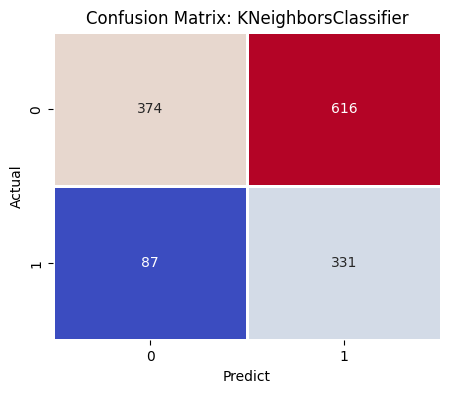

              precision    recall  f1-score   support

           0       0.81      0.38      0.52       990
           1       0.35      0.79      0.48       418

    accuracy                           0.50      1408
   macro avg       0.58      0.58      0.50      1408
weighted avg       0.67      0.50      0.51      1408

----------------------------------------------------------------------------------------------------
--------- BernoulliNB model --------------------


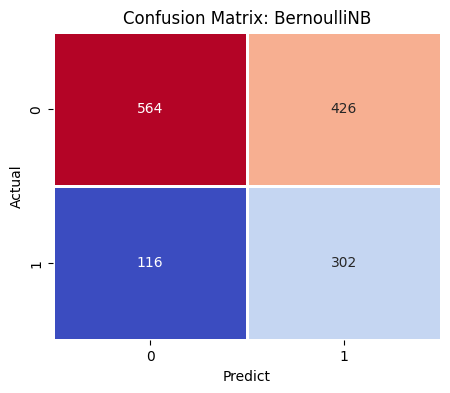

              precision    recall  f1-score   support

           0       0.83      0.57      0.68       990
           1       0.41      0.72      0.53       418

    accuracy                           0.62      1408
   macro avg       0.62      0.65      0.60      1408
weighted avg       0.71      0.62      0.63      1408

----------------------------------------------------------------------------------------------------
--------- DummyClassifier model --------------------


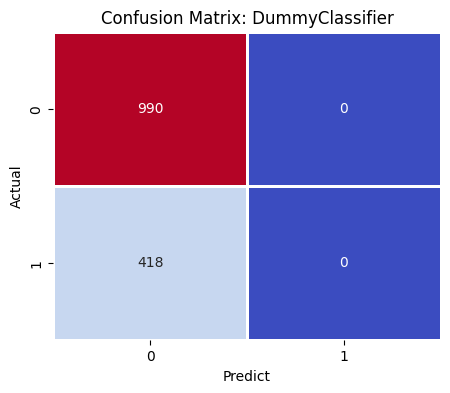

              precision    recall  f1-score   support

           0       0.70      1.00      0.83       990
           1       0.00      0.00      0.00       418

    accuracy                           0.70      1408
   macro avg       0.35      0.50      0.41      1408
weighted avg       0.49      0.70      0.58      1408

----------------------------------------------------------------------------------------------------


In [78]:
for name,model in models.items():
  print(f'--------- {name} model --------------------')
  model.fit(X_train_s,y_train_sm)
  y_pred = model.predict(X_test_s)

  plt.figure(figsize=(5, 4))
  plt.title(f"Confusion Matrix: {name}")
  sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,linewidths=1,cbar=False,cmap='coolwarm',fmt='d')
  plt.ylabel('Actual')
  plt.xlabel('Predict')
  plt.show()

  print(classification_report(y_test,y_pred))
  print('-----'*20)
